<a href="https://colab.research.google.com/github/zakyalkhair/alfagift-sentiment-analysis/blob/main/notebook/script-py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install google_play_scraper
!pip install textblob
from google_play_scraper import app
import pandas as pd
import numpy as np
import sklearn
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns
import textblob
#from wordcloud import WordCloud
from pathlib import Path
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report, accuracy_score

import pickle
import re
import time
import datetime                              # access to %%time, for timing individual notebook cells
import os
from PIL import Image
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

%matplotlib inline
%config InlineBackend.figure_format='retina'

sns.set_theme()
plt.rcParams["figure.figsize"] = (15,10)

In [ ]:
#Android App NHS link from Google Play at
#https://play.google.com/store/apps/details?id=com.alfamart.alfagift
#The apps ID found in the link after com.alfamart.alfagift
#The apps name on Google Play titled: Alfagift
#Dated Feb 19, 2026: number of reviews 305K

from google_play_scraper import app, Sort, reviews_all

alfagift_reviews = reviews_all(
    'com.alfamart.alfagift',
    sleep_milliseconds=0, # defaults to 0
    lang='id', # defaults to 'id'
    sort=Sort.NEWEST, # defaults to Sort.MOST_RELEVANT
)

In [ ]:
#Save the Alfagift Apps reviews into dataframe
df_alfagift = pd.DataFrame(np.array(alfagift_reviews),columns=['content'])
df_alfagiftrev = df_alfagift.join(pd.DataFrame(df_alfagift.pop('content').tolist()))
df_alfagiftrev.to_csv(r'df_alfagift.csv', index=False)
df_alfagift.head()

""
0
1
2
3
4


In [ ]:
print(df_alfagiftrev.reviewCreatedVersion.unique())
print(df_alfagiftrev.reviewCreatedVersion.nunique())

['4.47.1' '4.37.0' None '4.46.0' '4.44.1' '4.23.0' '4.45.0' '4.42.0'
 '4.43.0' '4.41.0' '4.47.0' '4.40.0' '4.45.1' '4.35.0' '4.27.1' '4.39.0'
 '4.33.0' '4.44.0' '4.19.0' '4.15.0' '4.34.0' '4.11.1' '4.31.0' '4.24.0'
 '4.10.0' '4.27.0' '4.28.0' '4.13.0' '4.38.0' '4.29.0' '4.36.0' '4.0.14'
 '4.25.0' '3.1.0' '4.12.1' '4.0.30' '4.32.0' '4.21.0' '4.20.1' '4.18.0'
 '4.22.0' '4.0.31' '4.0.15' '4.30.1' '4.0.29' '4.6.0' '4.9.0' '4.2.1'
 '4.3.0' '4.17.0' '4.4.1' '4.1.1' '4.7.1' '4.26.0' '4.2.2' '4.0.32'
 '4.5.0' '4.11.0' '4.8.0' '4.0.5' '4.2.0' '4.0.1' '4.14.0' '4.7.0'
 '4.0.27' '4.4.0' '4.16.0' '3.2' '4.0.25' '3.7' '4.0.22' '4.0.26' '4.0.21'
 '4.0.16' '4.0.24' '4.0.2' '4.0.23' '4.30.0' '4.0.17' '4.0.19' '2.1.1'
 '4.20.0' '4.0.10' '4.0.6' '4.0.8' '4.0.11' '4.0.18' '4.0.12' '4.1.0'
 '4.0.13' '4.12.0' '1.0.10' '4.0.20' '4.0.0RC43' '4.0.28' '4.0.9' '1.0.13'
 '3.3' '1.0.9' '2.0.16' '3.6' '3.5' '1.0.12' '4.0.7' '3.4' '2.0.15']
105


In [ ]:
#We do not need data for column reviewId, userName, userImage so
#we will show only these column
df_alfagiftrev.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,0,4.47.1,2026-03-04 19:31:11,"Hai, Kak. Maaf sekali pesanan kuota gagal dan dana belum kembali. Kami siap membantu mempercepat proses pengembalian dana demi kenyamanan Kakak. Kakak dapat menghubungi Shalma melalui DM Instagram...",2026-03-05 04:35:20
1,"JANGAN DI DOWNLOAD APLIKASI INI TIDAK REKOMENDASI MEMANG MURAH TIDAK ADA ONGKIR PENGIRIMAN TAPI SANGAT LAMA DI ANTER NYA Ber JAM JAM, SLOW RESPON CHAT TIDAK DI BALAS, LOKASIH PA39-DS DEMANG LEBAR ...",1,0,4.47.1,2026-03-04 14:59:22,None,NaT
2,Good Apls,5,0,4.47.1,2026-03-04 14:50:16,None,NaT
3,oke,4,0,4.37.0,2026-03-04 13:31:35,None,NaT
4,"first time ordering, success^^",5,0,None,2026-03-04 11:04:52,"Hai, Kak! Senang sekali pesanan pertama Kakak berjalan lancar. Semoga pengalaman belanja di Alfagift selalu menyenangkan dan praktis buat Kakak ke depannya. Terima kasih banyak atas kepercayaannya...",2026-03-05 12:00:11
...,...,...,...,...,...,...,...
170379,Terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,1,None,2015-06-24 13:49:06,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:52
170380,Alfamart belanja puas harga pas....,5,0,None,2015-06-24 11:45:03,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:46
170381,Ameijing,5,2,1.0.9,2015-06-24 11:17:29,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:32
170382,Keren banget .....,5,1,1.0.9,2015-06-24 09:37:25,Terimakasih atas dukungan anda. Dukungan 5 bintang anda adalah motivasi kami untuk maju.\n,2015-09-29 04:57:34


In [ ]:
!pip install emoji

import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", 200)
#from pandas_profiling import ProfileReport
import regex
import nltk
import wordcloud
import textblob

from nltk import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob

import string
import re
import emoji

In [ ]:
#Creating polarity on the column: content (review from the apps) using TextBlob
#Read https://textblob.readthedocs.io/en/dev/quickstart.html

from textblob import TextBlob
# Ensure 'content' column has no None values and is of string type
df_alfagiftrev['content'] = df_alfagiftrev['content'].fillna('').astype(str)
df_alfagiftrev['sentiment_polarity'] = df_alfagiftrev['content'].apply(lambda x: TextBlob(x).polarity)
df_alfagiftrev['sentiment_subjective'] = df_alfagiftrev['content'].apply(lambda x: TextBlob(x).subjectivity)

In [ ]:
#df_nhsrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","at"]]
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective"]]

,content,score,sentiment_polarity,sentiment_subjective
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,0.000,0.000000
1,"JANGAN DI DOWNLOAD APLIKASI INI TIDAK REKOMENDASI MEMANG MURAH TIDAK ADA ONGKIR PENGIRIMAN TAPI SANGAT LAMA DI ANTER NYA Ber JAM JAM, SLOW RESPON CHAT TIDAK DI BALAS, LOKASIH PA39-DS DEMANG LEBAR ...",1,-0.300,0.400000
2,Good Apls,5,0.700,0.600000
3,oke,4,0.000,0.000000
4,"first time ordering, success^^",5,0.275,0.166667
...,...,...,...,...
170379,Terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000,0.000000
170380,Alfamart belanja puas harga pas....,5,0.000,0.000000
170381,Ameijing,5,0.000,0.000000
170382,Keren banget .....,5,0.000,0.000000


In [ ]:
#Check number of reviews scores
df_alfagiftrev['score'].value_counts()

,count
score,
5,125794
1,25893
3,6662
2,6258
4,5777


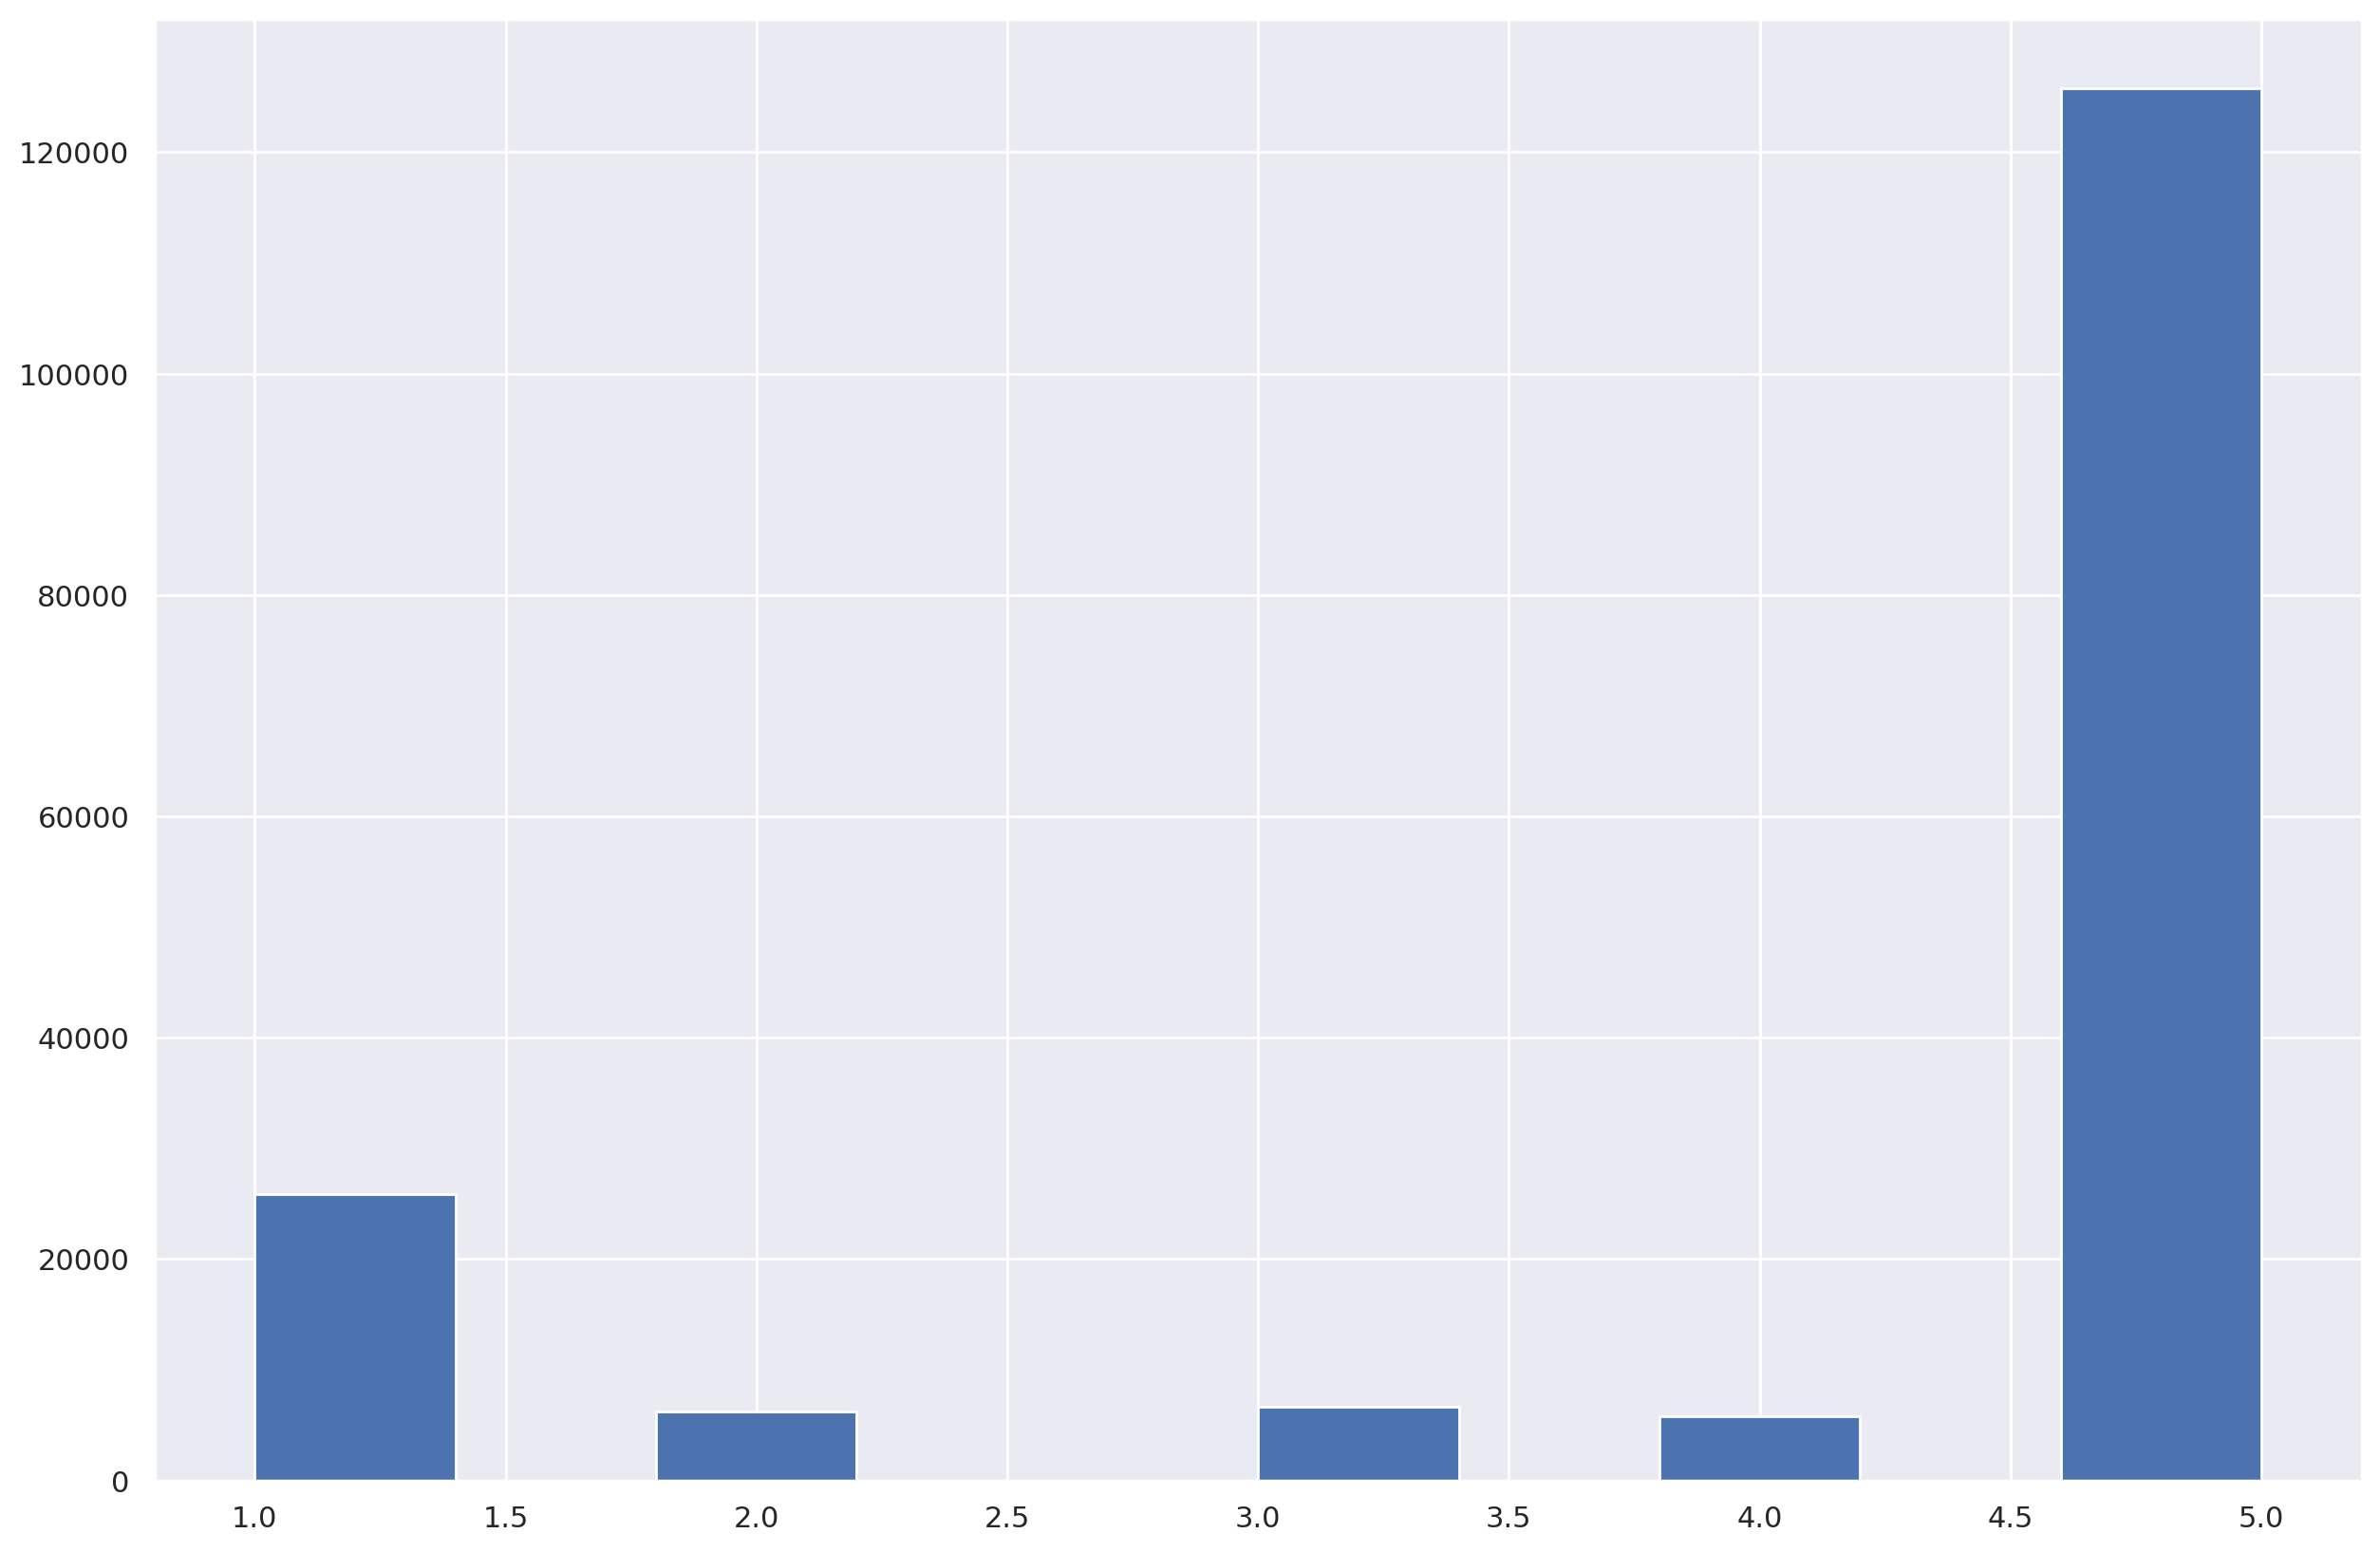

In [ ]:
plt.hist(df_alfagiftrev['score'])
plt.show()

In [ ]:
#DATA PREPROCESSING
# Lower casing

# Change the reviews type to string
df_alfagiftrev['content'] = df_alfagiftrev['content'].astype(str)# Before lowercasing
# Before lowercasing
print(df_alfagiftrev['content'][22442])

semakin mudah meriah


In [ ]:
#Lowercase all reviews to see the difference
df_alfagiftrev['content']= df_alfagiftrev['content'].apply(lambda x: x.lower())
print(df_alfagiftrev['content'][22442])

semakin mudah meriah


In [ ]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_alfagiftrev['wordCount'] = [len(review.split()) for review in df_alfagiftrev['content']]

df_alfagiftrev['uppercaseCharCount'] = [sum(char.isupper() for char in review) \
                              for review in df_alfagiftrev['content']]

df_alfagiftrev['specialCharCount'] = [sum(char in string.punctuation for char in review) \
                            for review in df_alfagiftrev['content']]

In [ ]:
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,0.000,0.000000,67,0,5
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...",1,-0.300,0.400000,34,0,3
2,good apls,5,0.700,0.600000,2,0,0
3,oke,4,0.000,0.000000,1,0,0
4,"first time ordering, success^^",5,0.275,0.166667,4,0,3
...,...,...,...,...,...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000,0.000000,8,0,6
170380,alfamart belanja puas harga pas....,5,0.000,0.000000,5,0,4
170381,ameijing,5,0.000,0.000000,1,0,0
170382,keren banget .....,5,0.000,0.000000,3,0,5


In [ ]:
#Removing stopwords
#Using nltk
import nltk
from nltk.corpus import stopwords
from nltk import word_tokenize, sent_tokenize
from nltk import FreqDist
from nltk.corpus import stopwords, wordnet
from nltk.stem import PorterStemmer
from nltk.stem.wordnet import WordNetLemmatizer


from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

from string import punctuation

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from tensorflow.keras.callbacks import EarlyStopping


In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

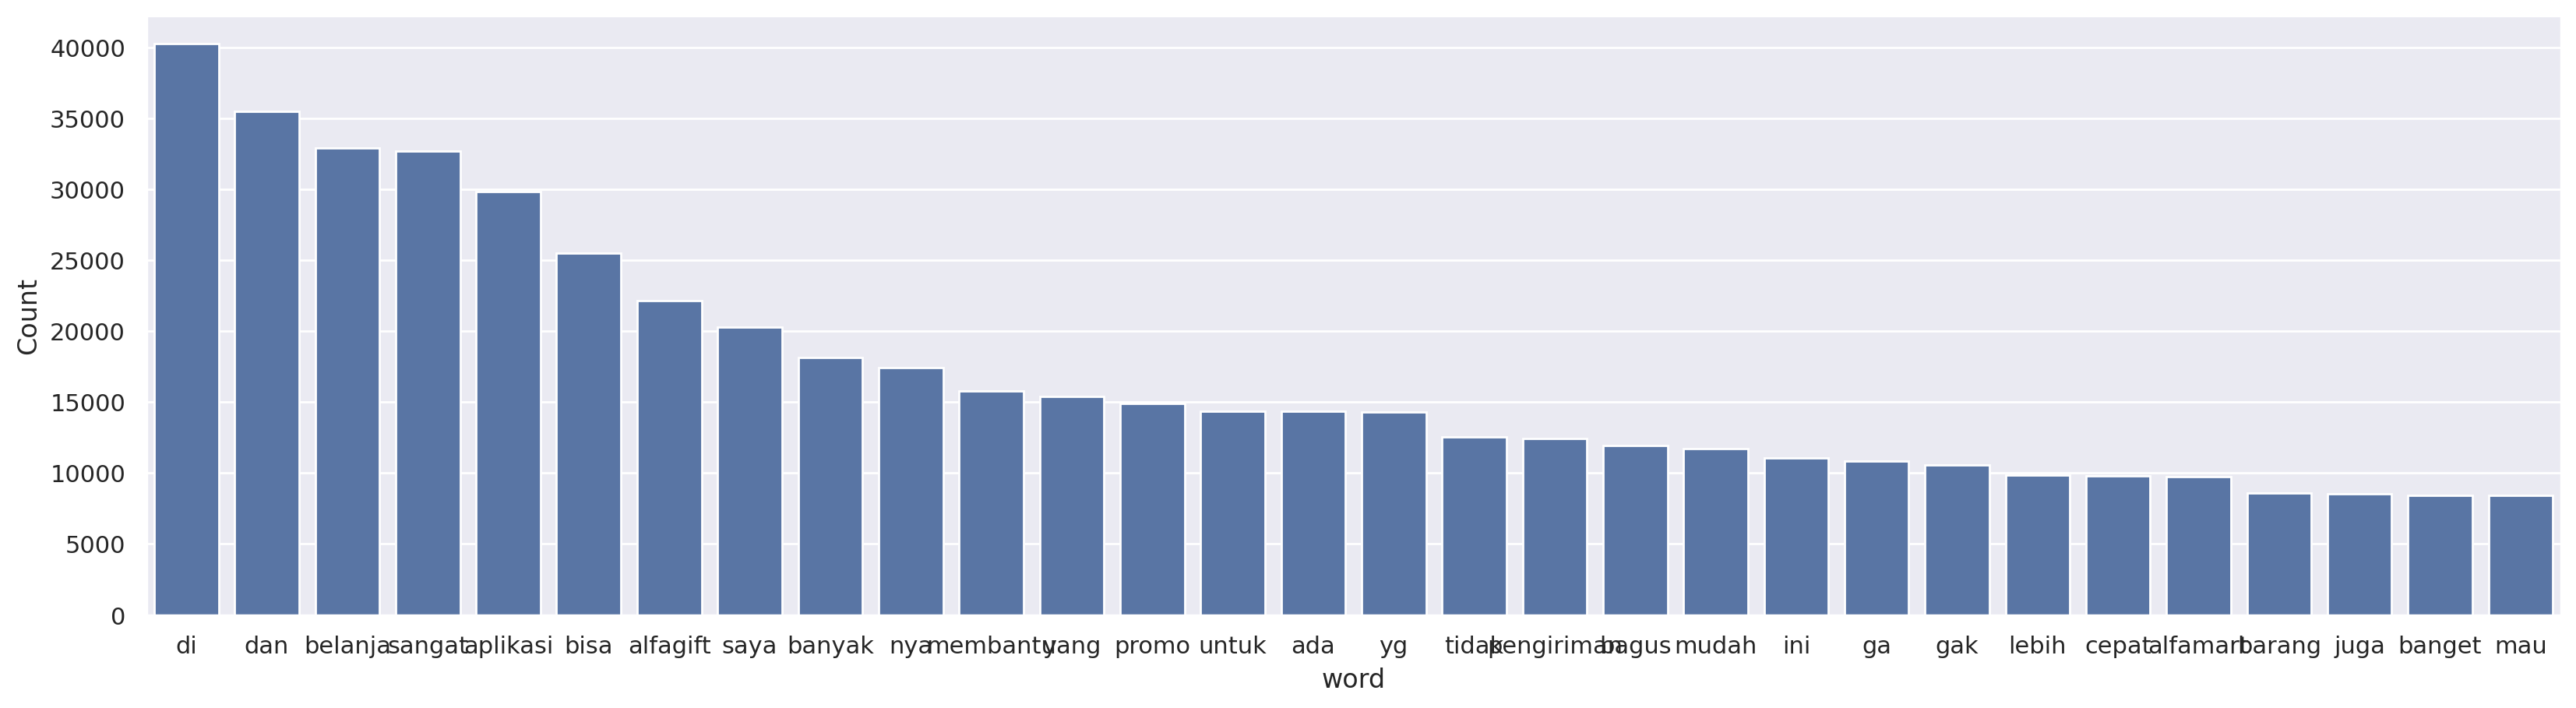

In [ ]:
freq_words(df_alfagiftrev['content'])

In [ ]:
#check if there is any special character
alphabet = string.ascii_letters+string.punctuation
print(df_alfagiftrev.content.str.strip(alphabet).astype(bool).any())

extracted_emojis=[]

def extract_emojis(s):
    expe = re.compile('[\U00010000-\U0010ffff]', flags=re.UNICODE)
    return expe.findall(s)
    return expe.sub(r'',s)

for y in df_alfagiftrev['content']:
    #print(str(extract_emojis(y)))
    extracted_emojis.append(str(extract_emojis(y)))

print(extracted_emojis)

True
["['😡', '😡']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😑']", '[]', '[]', "['🙏']", '[]', "['🥲']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['😭']", "['🤯']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🙏']", '[]', '[]', '[]', '[]', "['😹']", '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', '[]', "['🫠']", '[]', '[]', "['🤣', '🫶']", "['🥰']", '[]', '[]', '[]

In [ ]:
df_alfagiftrev.loc[:,["content", "score","sentiment_polarity", "sentiment_subjective","wordCount","uppercaseCharCount","specialCharCount"]]

,content,score,sentiment_polarity,sentiment_subjective,wordCount,uppercaseCharCount,specialCharCount
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,0.000,0.000000,67,0,5
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...",1,-0.300,0.400000,34,0,3
2,good apls,5,0.700,0.600000,2,0,0
3,oke,4,0.000,0.000000,1,0,0
4,"first time ordering, success^^",5,0.275,0.166667,4,0,3
...,...,...,...,...,...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000,0.000000,8,0,6
170380,alfamart belanja puas harga pas....,5,0.000,0.000000,5,0,4
170381,ameijing,5,0.000,0.000000,1,0,0
170382,keren banget .....,5,0.000,0.000000,3,0,5


In [ ]:
#Add a column name polarity_rating from changing the score of the review into 3 labels: Pos, Negative Neutral
df_alfagiftrev['sentiment_rating'] = df_alfagiftrev['score'].apply(lambda x: 'Positive' if x > 3 else('Neutral' if x == 3  else 'Negative'))

In [ ]:
df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

,content,score,sentiment_polarity,sentiment_subjective,sentiment_rating
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,0.000,0.000000,Negative
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...",1,-0.300,0.400000,Negative
2,good apls,5,0.700,0.600000,Positive
3,oke,4,0.000,0.000000,Positive
4,"first time ordering, success^^",5,0.275,0.166667,Positive
...,...,...,...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000,0.000000,Positive
170380,alfamart belanja puas harga pas....,5,0.000,0.000000,Positive
170381,ameijing,5,0.000,0.000000,Positive
170382,keren banget .....,5,0.000,0.000000,Positive


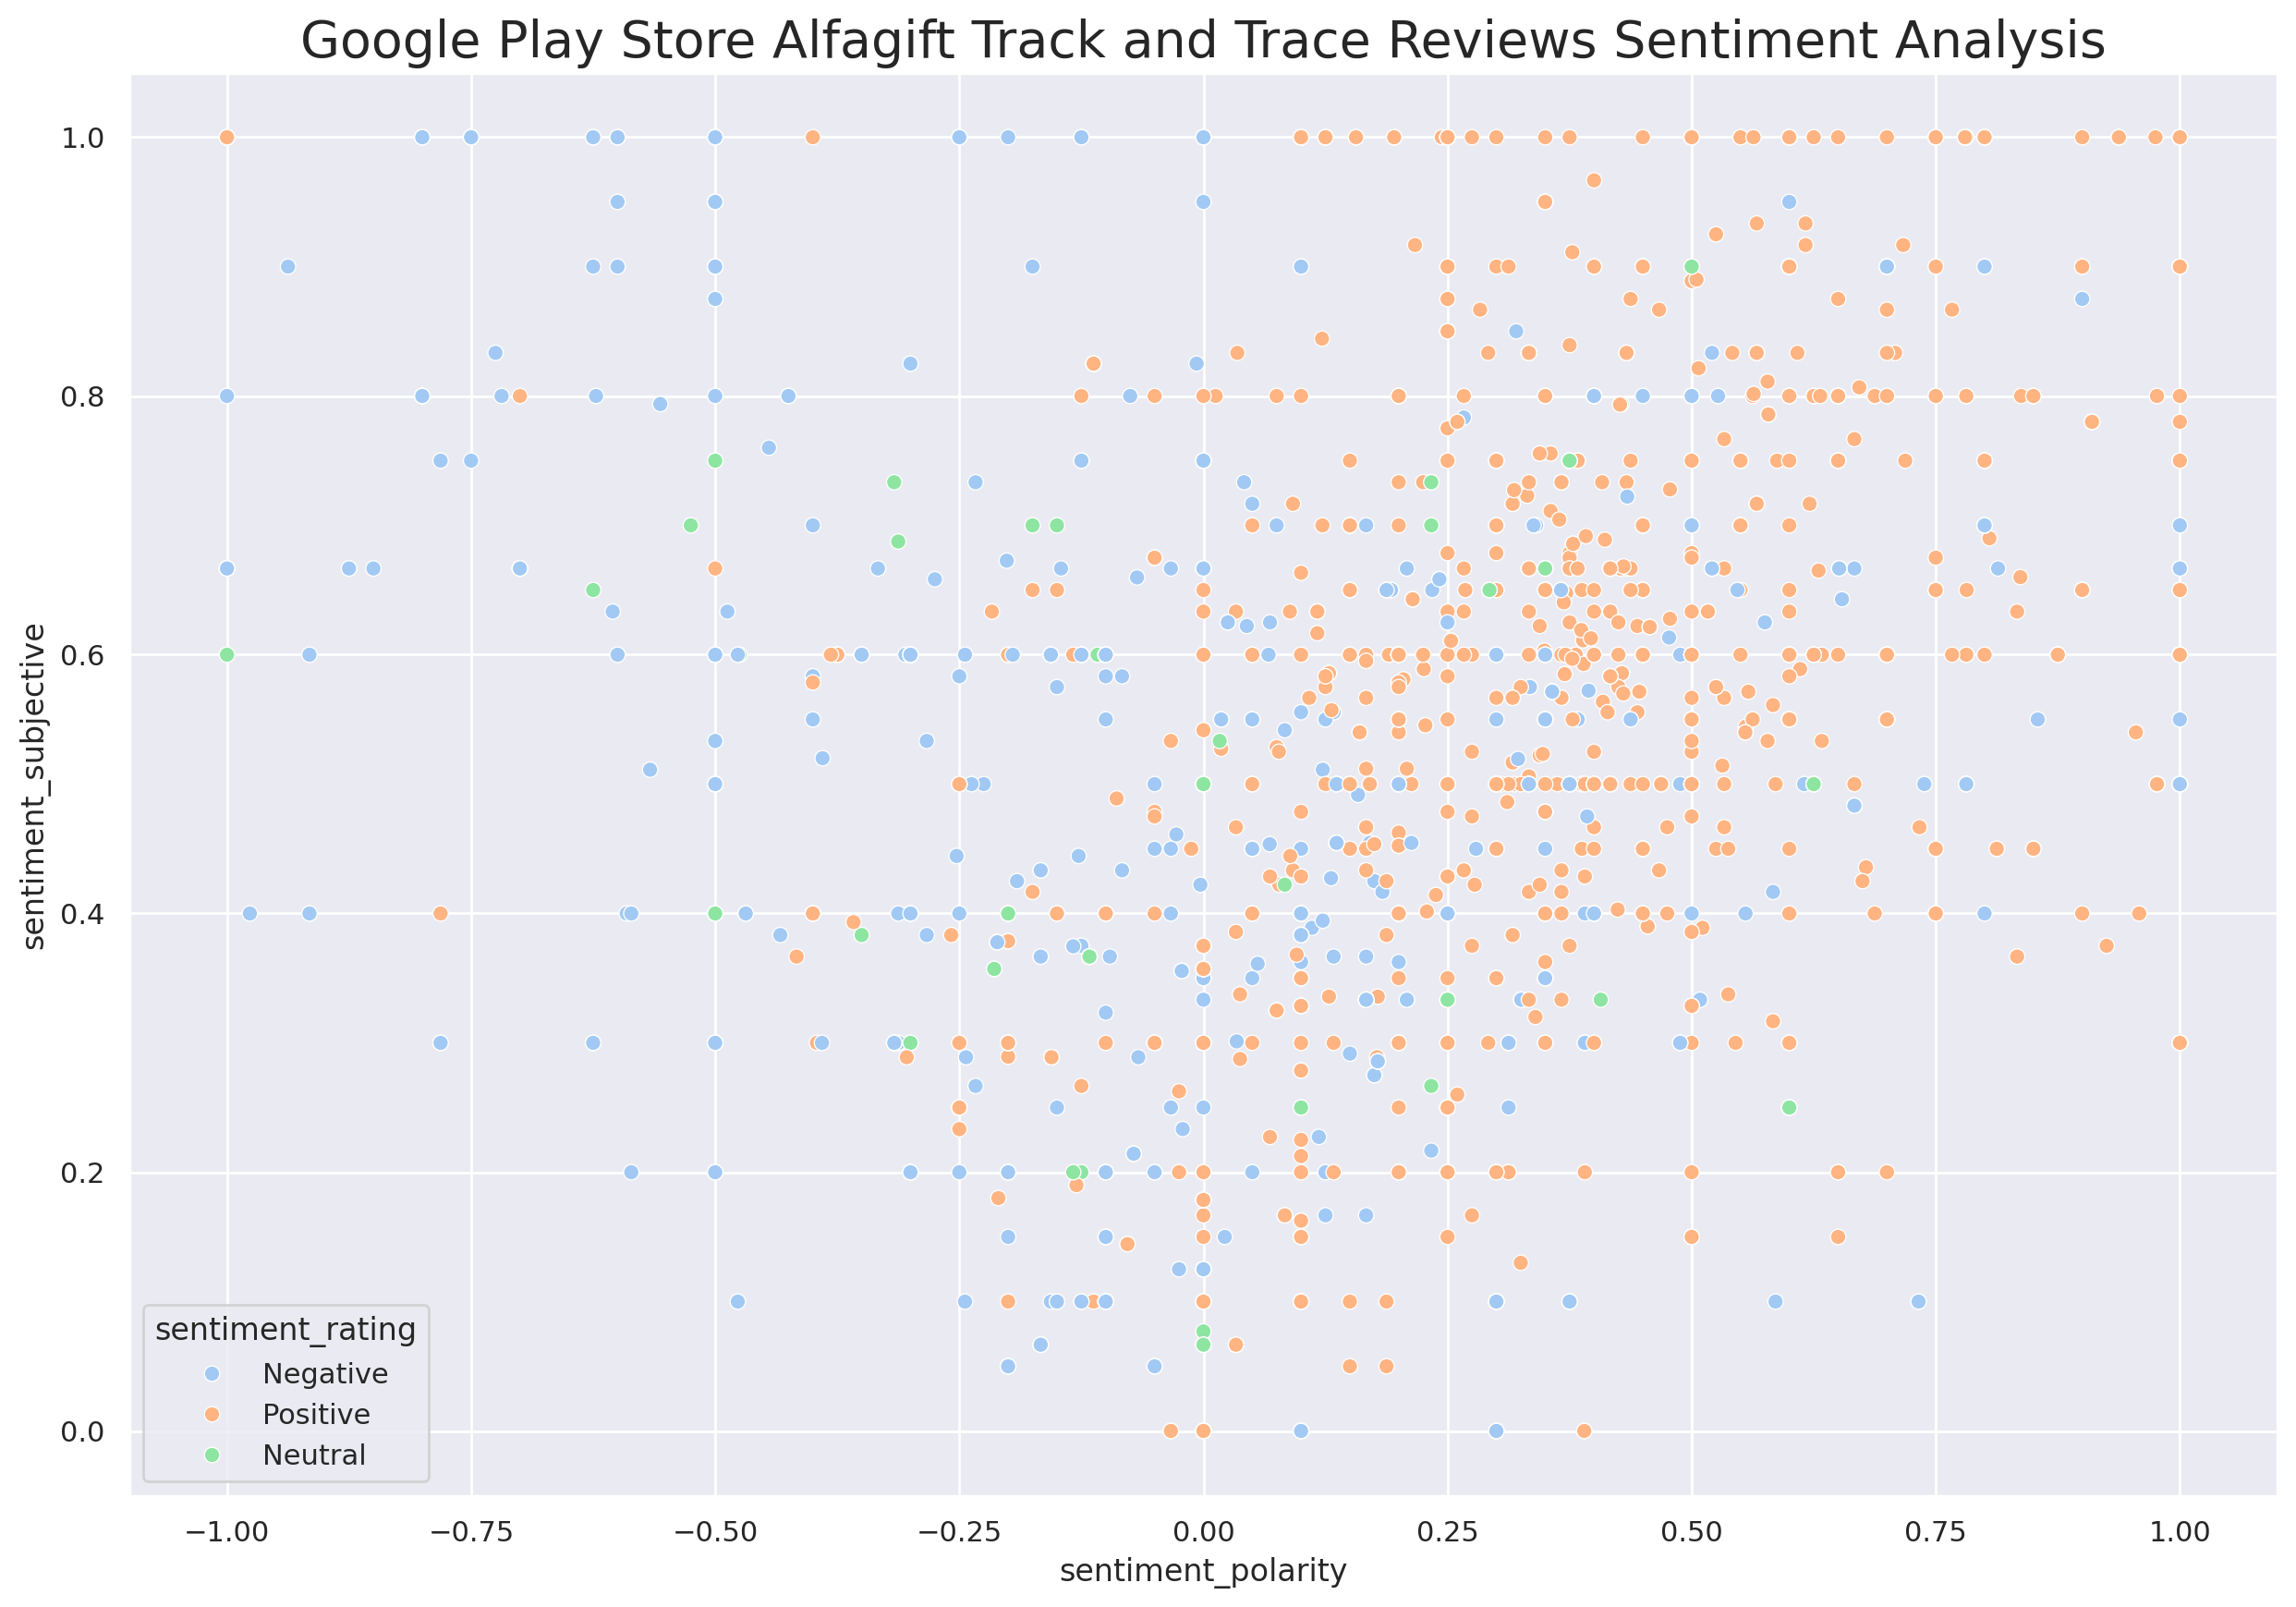

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df_alfagiftrev['sentiment_polarity'], y=df_alfagiftrev['sentiment_subjective'],
                hue = df_alfagiftrev['sentiment_rating'], edgecolor='white', palette="pastel")
plt.title("Google Play Store Alfagift Track and Trace Reviews Sentiment Analysis", fontsize=20)
plt.show()

In [ ]:
#Print the extracted emojis review column (content) before stopwords
df_alfagiftrev.to_csv(r'df_alfagiftrev_before_stopwords_sentiment_rating.csv', index = False)

In [ ]:
import nltk
from nltk.corpus import stopwords

# Download Indonesian stopwords if not already downloaded
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

stop = stopwords.words('english') + ["someone","still","would","need", "gak", "ga", "yg", "aja", "nya", "gk" ,",", "."]
stop.extend(stopwords.words('indonesian'))
print(stop)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
print(len(stop))

968


In [ ]:
df_alfagiftrev_stopwords = df_alfagiftrev.loc[:,["content","score","sentiment_polarity", "sentiment_subjective","sentiment_rating"]]

In [ ]:
# Exclude stopwords
df_alfagiftrev_stopwords['tweet_without_stopwords'] = df_alfagiftrev_stopwords['content'].apply(lambda x: ' '.join([word for word in x.split() if word not in (stop)]))
df_alfagiftrev_stopwords.loc[:,["content","tweet_without_stopwords"]]

,content,tweet_without_stopwords
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...","udit ku balikin dah 2 pengajuan respon sekali,nyesel beli kuota alfagif udah bayaran pesanan gagal,al hasil uang ku ketahan seratus ribu lebih,tolong perbaiki customer service lambat banget penaga..."
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...","download aplikasi rekomendasi murah ongkir pengiriman anter ber jam jam, slow respon chat balas, lokasih pa39-ds demang lebar daun palembang"
2,good apls,good apls
3,oke,oke
4,"first time ordering, success^^","first time ordering, success^^"
...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,terobosannya memudahkan pelanggan mampir...mampir...dan mampir
170380,alfamart belanja puas harga pas....,alfamart belanja puas harga pas....
170381,ameijing,ameijing
170382,keren banget .....,keren banget .....


In [ ]:
# pat = r'\b(?:{})\b'.format('|'.join(stop))
# The lines below are removed as the stopword removal is already handled by cell 37f3557d
# df_alfagiftrev_stopwords['tweet_without_stopwords'] = df_alfagiftrev_stopwords['content'].str.replace(pat, '')
# df_alfagiftrev_stopwords['tweet_without_stopwords'] = df_alfagiftrev_stopwords['tweet_without_stopwords'].str.replace(r'\s+', ' ')
print(df_alfagiftrev_stopwords)

                                                                                                                                                                                                        content  \
0       udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...   
1       jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...   
2                                                                                                                                                                                                     good apls   
3                                                                                                                                                           

In [ ]:
df_alfagiftrev_stopwords.loc[:,["content","tweet_without_stopwords"]]

,content,tweet_without_stopwords
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...","udit ku balikin dah 2 pengajuan respon sekali,nyesel beli kuota alfagif udah bayaran pesanan gagal,al hasil uang ku ketahan seratus ribu lebih,tolong perbaiki customer service lambat banget penaga..."
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...","download aplikasi rekomendasi murah ongkir pengiriman anter ber jam jam, slow respon chat balas, lokasih pa39-ds demang lebar daun palembang"
2,good apls,good apls
3,oke,oke
4,"first time ordering, success^^","first time ordering, success^^"
...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,terobosannya memudahkan pelanggan mampir...mampir...dan mampir
170380,alfamart belanja puas harga pas....,alfamart belanja puas harga pas....
170381,ameijing,ameijing
170382,keren banget .....,keren banget .....


In [ ]:
#Save into csv after applying stopwords
df_alfagiftrev_stopwords.to_csv(r'df_alfagiftrev_after_stopwords_sentiment_rating2.csv', index = False)

In [ ]:
#Count after stopwords
#edited from https://www.tensorscience.com/nlp/sentiment-analysis-tutorial-in-python-classifying-reviews-on-movies-and-products
import string

df_alfagiftrev_stopwords['wordCount'] = [len(review.split()) for review in df_alfagiftrev_stopwords['content']]
df_alfagiftrev_stopwords['wordCount_after_stopwords'] = [len(review.split()) for review in df_alfagiftrev_stopwords['tweet_without_stopwords']]


In [ ]:
df_alfagiftrev_stopwords.loc[:,["content","score","sentiment_polarity", "sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_polarity,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,0.000,Negative,67,"udit ku balikin dah 2 pengajuan respon sekali,nyesel beli kuota alfagif udah bayaran pesanan gagal,al hasil uang ku ketahan seratus ribu lebih,tolong perbaiki customer service lambat banget penaga...",47
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...",1,-0.300,Negative,34,"download aplikasi rekomendasi murah ongkir pengiriman anter ber jam jam, slow respon chat balas, lokasih pa39-ds demang lebar daun palembang",20
2,good apls,5,0.700,Positive,2,good apls,2
3,oke,4,0.000,Positive,1,oke,1
4,"first time ordering, success^^",5,0.275,Positive,4,"first time ordering, success^^",4
...,...,...,...,...,...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,0.000,Positive,8,terobosannya memudahkan pelanggan mampir...mampir...dan mampir,5
170380,alfamart belanja puas harga pas....,5,0.000,Positive,5,alfamart belanja puas harga pas....,5
170381,ameijing,5,0.000,Positive,1,ameijing,1
170382,keren banget .....,5,0.000,Positive,3,keren banget .....,3


In [ ]:
# function to plot most frequent terms
def freq_words(x, terms = 30):
  all_words = ' '.join([text for text in x])
  all_words = all_words.split()

  fdist = FreqDist(all_words)
  words_df = pd.DataFrame({'word':list(fdist.keys()), 'count':list(fdist.values())})

  # selecting top 20 most frequent words
  d = words_df.nlargest(columns="count", n = terms)
  plt.figure(figsize=(20,5))
  ax = sns.barplot(data=d, x= "word", y = "count")
  ax.set(ylabel = 'Count')
  plt.show()

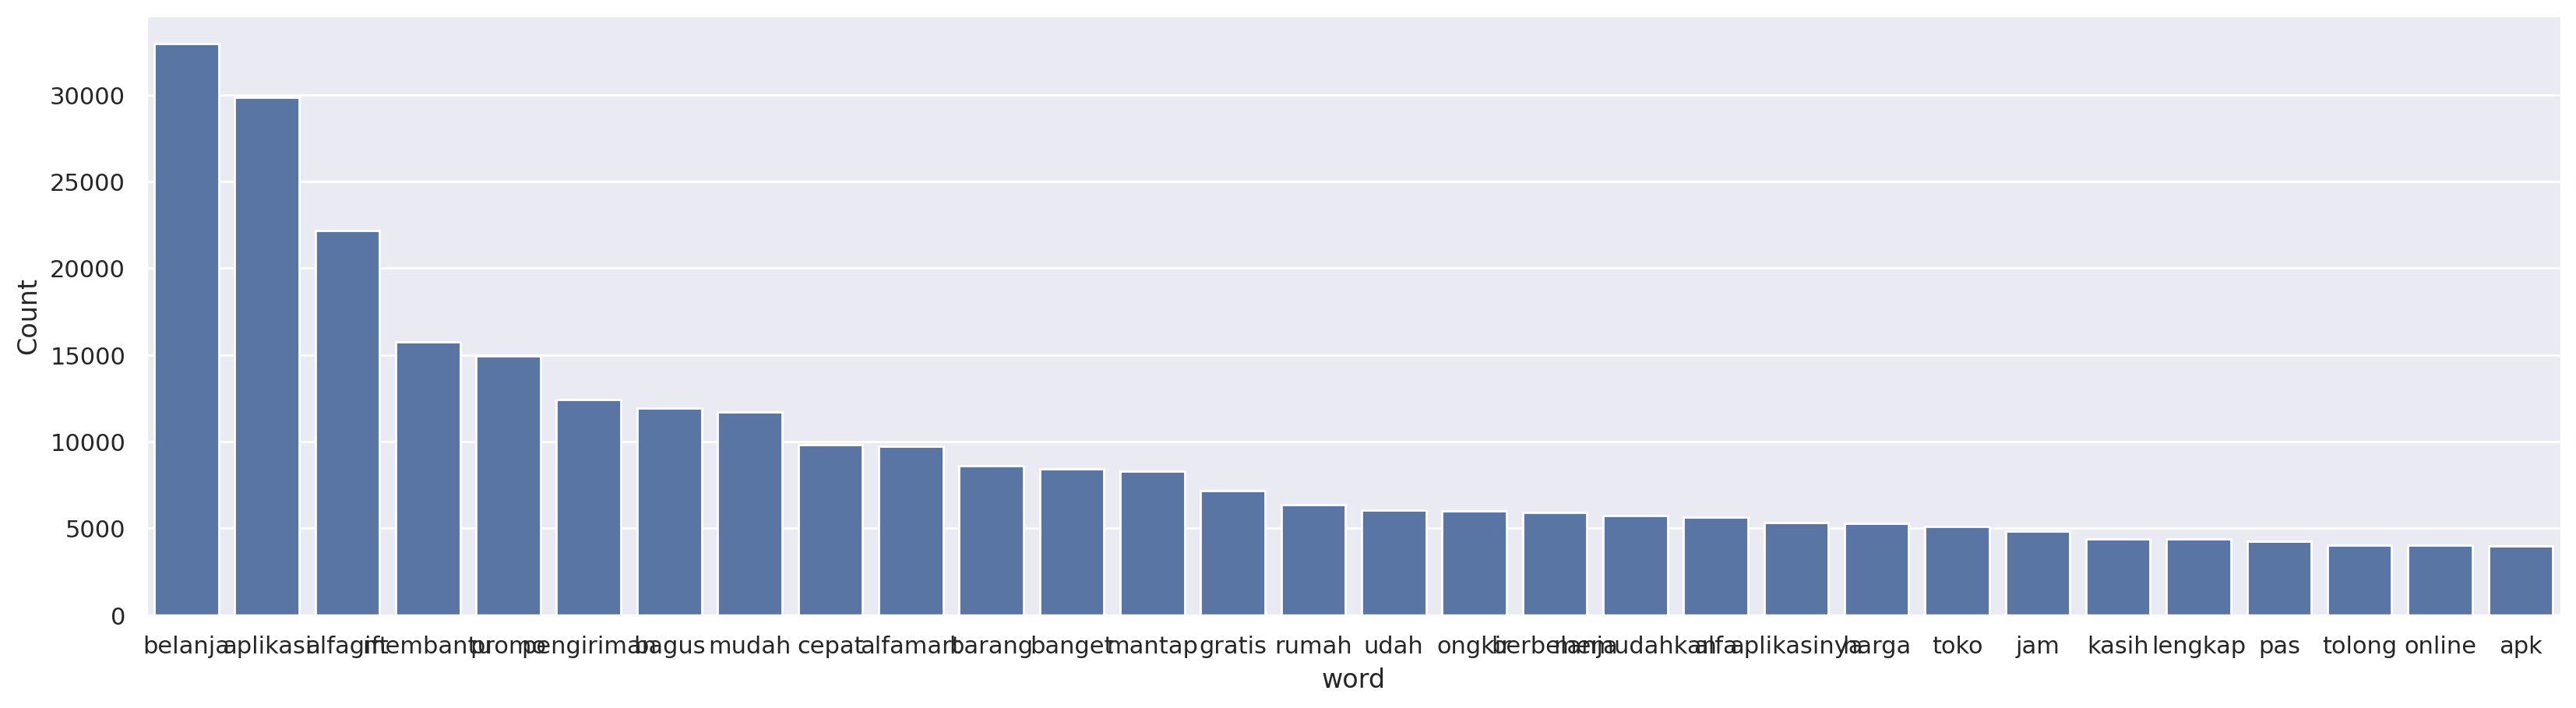

In [ ]:
freq_words(df_alfagiftrev_stopwords['tweet_without_stopwords'])

In [ ]:
newStopWords = ["'",".",",", "someone","still","would","need",""]

#from nltk.corpus import stopwords
#stoplist = stopwords.words('english') + ['though']

#NOT YET DONE ==== 24 May 2022

In [ ]:
#Stemming

#Stemming function chops off the end of the word
#and transform the word into its root form.
#All suffixes like -s, -es, -ed, -ing are removed.

def stemming(x):
    st = PorterStemmer()
    if x is not None:
       for word in x.split():
           st.stem(word)

df_alfagiftrev_stopwords['tweet_without_stopwords'].apply(lambda x:stemming(x))
print(df_alfagiftrev_stopwords['tweet_without_stopwords'][22439])

pelayanan bagus


In [ ]:
#DROP NA
df_alfagiftrev_stopwords.dropna(inplace=True)
df_alfagiftrev_stopwords.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170384 entries, 0 to 170383
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   content                    170384 non-null  object 
 1   score                      170384 non-null  int64  
 2   sentiment_polarity         170384 non-null  float64
 3   sentiment_subjective       170384 non-null  float64
 4   sentiment_rating           170384 non-null  object 
 5   tweet_without_stopwords    170384 non-null  object 
 6   wordCount                  170384 non-null  int64  
 7   wordCount_after_stopwords  170384 non-null  int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 10.4+ MB


In [ ]:
df_alfagiftrev_stopwords.loc[:,["content","score","sentiment_rating","wordCount","tweet_without_stopwords", "wordCount_after_stopwords"]]

,content,score,sentiment_rating,wordCount,tweet_without_stopwords,wordCount_after_stopwords
0,"udit ku balikin dah 2 hari pengajuan ga ada respon sama sekali,nyesel beli kuota di alfagif udah di bayaran tapi pesanan nya gagal,al hasil uang ku ketahan seratus ribu lebih,tolong di perbaiki cu...",1,Negative,67,"udit ku balikin dah 2 pengajuan respon sekali,nyesel beli kuota alfagif udah bayaran pesanan gagal,al hasil uang ku ketahan seratus ribu lebih,tolong perbaiki customer service lambat banget penaga...",47
1,"jangan di download aplikasi ini tidak rekomendasi memang murah tidak ada ongkir pengiriman tapi sangat lama di anter nya ber jam jam, slow respon chat tidak di balas, lokasih pa39-ds demang lebar ...",1,Negative,34,"download aplikasi rekomendasi murah ongkir pengiriman anter ber jam jam, slow respon chat balas, lokasih pa39-ds demang lebar daun palembang",20
2,good apls,5,Positive,2,good apls,2
3,oke,4,Positive,1,oke,1
4,"first time ordering, success^^",5,Positive,4,"first time ordering, success^^",4
...,...,...,...,...,...,...
170379,terobosannya memudahkan pelanggan untuk selalu mampir...mampir...dan mampir lagi,5,Positive,8,terobosannya memudahkan pelanggan mampir...mampir...dan mampir,5
170380,alfamart belanja puas harga pas....,5,Positive,5,alfamart belanja puas harga pas....,5
170381,ameijing,5,Positive,1,ameijing,1
170382,keren banget .....,5,Positive,3,keren banget .....,3
